# DukaStock — Notebook 2: ML Benchmark Experiment

**Primary research question:** Across SARIMA, Prophet, XGBoost, and N-BEATS,
at what minimum data density does each model class first achieve statistically
significant improvement over a naive last-week-sales baseline (p < 0.05,
Diebold-Mariano test with Newey-West variance correction), when trained under
simulated cold-start conditions at 6 density levels (5 / 15 / 30 / 50 / 75 /
100 %) using walk-forward cross-validation with a 7-day horizon, **evaluated
at the individual store (single-Duka proxy) level**?

### Why store-level evaluation, not national aggregate

DukaStock serves individual shopkeepers, not national retailers. Aggregating
10 stores into one national series inflates lag-7 autocorrelation to r = 0.94
(R² = 88 %), leaving only 12 % of variance for any model to improve on and
making Diebold-Mariano significance nearly unachievable regardless of model
quality. At the single-store level, lag-7 autocorrelation drops to r = 0.55–
0.80 (R² = 30–64 %) depending on product, giving a realistic margin for ML
improvement and a fair DM test. Each Kaggle 'store' serves as a proxy for
one Duka; metrics are computed per store and then averaged.

### Honest limitation on Rwanda localisation

The underlying dataset is the **Kaggle Store Item Demand Forecasting
Challenge** (anonymous retail data, origin unknown). The Rwanda localisation
layer — holiday calendar, Genocide Memorial Day suppressor, rainy-season
intensity, product naming — is **fully implemented and designed for
deployment** on real Duka sales data. It cannot be validated on this proxy
dataset because the sales values have no relationship to Rwandan public
events. This is disclosed explicitly here and in the thesis methods section.

### Running on Google Colab (recommended)

1. Upload this notebook to [colab.research.google.com](https://colab.research.google.com).
2. Enable GPU: **Runtime → Change runtime type → T4 GPU**.
3. Run **Cell 0** first — it mounts your Google Drive at `/content/drive/MyDrive/DukaStock/`.
4. Upload `fmcg_rwanda_localized.csv` into that Drive folder before running Cell 3.
5. After Cell 12 finishes, results are automatically saved back to Drive.

**Expected runtime:** ~10–14 hours (Colab/Kaggle GPU). Set
`RUN_ALL_STORES = False` in Cell 11 to use 5 stores (~5–7 hours) if the
session limit is a concern.


In [1]:
# Cell 0 — Environment detection: Google Colab, GPU, and Google Drive
import os, sys

# ── Detect whether we are inside Google Colab ────────────────────────────────
IN_COLAB = False
try:
    import google.colab  # noqa: F401  — import succeeds only inside Colab
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    print("Running on Google Colab.")
    from google.colab import drive
    drive.mount("/content/drive")
    # All DukaStock files (CSV input, results output) go here.
    DRIVE_ROOT = "/content/drive/MyDrive/DukaStock"
    os.makedirs(DRIVE_ROOT, exist_ok=True)
    print(f"Google Drive mounted. DukaStock folder: {DRIVE_ROOT}")
    print("  → Place fmcg_rwanda_localized.csv inside that Drive folder before running Cell 3.")
else:
    DRIVE_ROOT = None
    print("Not running on Google Colab — using local paths only.")

# ── GPU check (logged here; used in Cell 10 for N-BEATS accelerator) ─────────
import torch
ON_GPU = torch.cuda.is_available()
print("CUDA available:", ON_GPU)
if ON_GPU:
    print("GPU:", torch.cuda.get_device_name(0))
    total_mem = torch.cuda.get_device_properties(0).total_memory
    print(f"GPU memory: {total_mem / 1e9:.1f} GB")
else:
    print("No GPU — N-BEATS will run on CPU (slower). SARIMA/Prophet/XGBoost are unaffected.")
    print("  On Colab:  Runtime → Change runtime type → T4 GPU")
    print("  On Kaggle: Settings → Accelerator → GPU T4 x2")


Not running on Google Colab — using local paths only.
CUDA available: False
No GPU — N-BEATS will run on CPU (slower). SARIMA/Prophet/XGBoost are unaffected.
  On Colab:  Runtime → Change runtime type → T4 GPU
  On Kaggle: Settings → Accelerator → GPU T4 x2


In [2]:
# Cell 1 — Install dependencies
import sys, subprocess

def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

# accelerate: required by neuralforecast (N-BEATS) for GPU training
required = [
    ("pmdarima",       "pmdarima"),
    ("prophet",        "prophet"),
    ("neuralforecast", "neuralforecast"),
    ("seaborn",        "seaborn"),
    ("accelerate",     "accelerate"),
]
for pkg, import_name in required:
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {pkg} ...")
        pip_install([pkg])

print("Dependencies ready.")


/Users/abizera/Documents/ALU/Capstone/dukastock 2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/abizera/Documents/ALU/Capstone/dukastock 2/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
2026-06-30 09:19:57,815	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-30 09:19:58,231	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Dependencies ready.


In [3]:
# Cell 2 — Imports and reproducibility seed
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Fix all random seeds for full reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

try:
    import pmdarima as pm
    _SARIMA_OK = True
except ImportError:
    _SARIMA_OK = False

try:
    from prophet import Prophet
    _PROPHET_OK = True
except ImportError:
    _PROPHET_OK = False

try:
    import xgboost as xgb
    from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
    _XGB_OK = True
except ImportError:
    _XGB_OK = False

try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import NBEATS
    _NBEATS_OK = True
except ImportError:
    _NBEATS_OK = False

print(f"SARIMA available: {_SARIMA_OK} | Prophet available: {_PROPHET_OK} | "
      f"XGBoost available: {_XGB_OK} | N-BEATS available: {_NBEATS_OK}")
print(f"Reproducibility seed: {RANDOM_SEED}")


SARIMA available: True | Prophet available: True | XGBoost available: True | N-BEATS available: True


In [4]:
# Cell 3 — Load the Rwanda-localized dataset produced by Notebook 1
#
# We keep the data at the individual-store level. Each (store, product)
# pair is a proxy for one Duka. The experiment loop in Cell 11 iterates
# over all (store, product) pairs and averages metrics across stores.

import glob

CANDIDATE_PATHS = [
    Path(f"{DRIVE_ROOT}/fmcg_rwanda_localized.csv") if DRIVE_ROOT else None,
    Path("/kaggle/working/fmcg_rwanda_localized.csv"),
    *[Path(p) for p in glob.glob("/kaggle/input/*/fmcg_rwanda_localized.csv")],
    Path("../data/fmcg_rwanda_localized.csv"),
    Path("ml_experiments/data/fmcg_rwanda_localized.csv"),
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if p and p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "fmcg_rwanda_localized.csv not found.\n"
        "  On Colab:  upload it to MyDrive/DukaStock/ and re-run this cell.\n"
        "  On Kaggle: add it as a dataset or copy it to /kaggle/working/.\n"
        "  Locally:   run Notebook 1 first."
    )

print(f"Loading data from: {DATA_PATH}")
fmcg = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(f"Loaded {fmcg.shape[0]:,} rows")
print(f"Stores: {sorted(fmcg['store'].unique())}")
print(f"Products: {sorted(fmcg['product_code'].unique())}")
print(f"Date range: {fmcg['date'].min().date()} → {fmcg['date'].max().date()}")

# Verify per-store series length
series_len = fmcg.groupby(['store','product_code']).size()
print(f"\nRows per (store, product): min={series_len.min()}, max={series_len.max()} "
      f"(expected 1826 = 5 years × 365.2 days)")

# Per-store autocorrelation report (honest characterisation of task difficulty)
print("\nPer-store lag-7 autocorrelation (determines how hard naive is to beat):")
for p in sorted(fmcg['product_code'].unique()):
    lags = []
    for s in sorted(fmcg['store'].unique()):
        y = fmcg[(fmcg['store']==s)&(fmcg['product_code']==p)].sort_values('date')['sales']
        lags.append(float(y.corr(y.shift(7))))
    print(f"  {p}: mean r={np.mean(lags):.3f}, R²={np.mean(lags)**2*100:.1f}% "
          f"(naive explains this much variance per-store)")

fmcg.head()


Loading data from: ../data/fmcg_rwanda_localized.csv
Loaded 91300 rows, products: ['FLOUR', 'OIL', 'RICE', 'SOAP', 'SUGAR']
National daily series shape: (9130, 11)


,date,product_code,sales,is_holiday,is_memorial,days_to_next_holiday,season_flag,rain_intensity,day_of_week,week_of_year,month
0,2013-01-01,FLOUR,444,1,0,0,0,0.434504,1,1,1
1,2013-01-01,OIL,278,1,0,0,0,0.434504,1,1,1
2,2013-01-01,RICE,349,1,0,0,0,0.434504,1,1,1
3,2013-01-01,SOAP,350,1,0,0,0,0.434504,1,1,1
4,2013-01-01,SUGAR,133,1,0,0,0,0.434504,1,1,1


## 1. Core experiment building blocks

These mirror `backend/app/ml/pipeline/cold_start.py` and
`backend/app/ml/evaluation/metrics.py` exactly, reproduced inline here so
this notebook is fully self-contained and Kaggle-runnable without needing
the backend package on the Python path.


In [5]:
# Cell 4 — Cold-start density slicing + walk-forward folds
DENSITY_LEVELS = [5, 15, 30, 50, 75, 100]
MIN_WALK_FORWARD_FOLDS = 6

def temporal_density_slice(series, density_pct, date_col='date'):
    ordered = series.sort_values(date_col).reset_index(drop=True)
    cutoff = max(1, int(len(ordered) * density_pct / 100))
    return ordered.iloc[:cutoff].copy()

def walk_forward_folds(series, date_col='date', horizon=7, min_folds=MIN_WALK_FORWARD_FOLDS):
    ordered = series.sort_values(date_col).reset_index(drop=True)
    n = len(ordered)
    usable_for_folds = min_folds * horizon
    min_train_size = max(14, n - usable_for_folds)
    if min_train_size >= n:
        min_train_size = max(7, n // 2)
    folds = []
    cursor = min_train_size
    while cursor + horizon <= n and len(folds) < min_folds:
        folds.append((ordered.iloc[:cursor], ordered.iloc[cursor:cursor + horizon]))
        cursor += horizon
    return folds

print("Density levels:", DENSITY_LEVELS)


Density levels: [5, 15, 30, 50, 75, 100]


In [6]:
# Cell 5 — Evaluation metrics + Diebold-Mariano test (Newey-West HAC variance)
def rmse(y_true, y_pred): return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
def mae(y_true, y_pred):  return float(np.mean(np.abs(y_true - y_pred)))

def mape(y_true, y_pred, eps=1e-8):
    denom = np.where(np.abs(y_true) < eps, eps, y_true)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def smape(y_true, y_pred, eps=1e-8):
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom < eps, eps, denom)
    return float(np.mean(2 * np.abs(y_true - y_pred) / denom) * 100)

def compute_all_metrics(y_true, y_pred):
    return {"rmse": rmse(y_true, y_pred), "mae": mae(y_true, y_pred),
            "mape": mape(y_true, y_pred), "smape": smape(y_true, y_pred)}

def diebold_mariano_test(y_true, y_pred_model, y_pred_baseline, loss="squared", h=7):
    """
    Diebold-Mariano (1995) test with Newey-West HAC variance for h-step-ahead
    forecasts (Harvey, Leybourne & Newbold, 1997 correction for h > 1).
    H0: equal predictive accuracy. significant_at_05 requires BOTH p < 0.05
    AND d_bar < 0 (model is directionally better, not just different).
    """
    e_m = y_true - y_pred_model
    e_b = y_true - y_pred_baseline
    loss_m = e_m**2 if loss == "squared" else np.abs(e_m)
    loss_b = e_b**2 if loss == "squared" else np.abs(e_b)
    d = loss_m - loss_b
    n = len(d)
    d_bar = float(np.mean(d))

    # Newey-West HAC: gamma_0 + 2 * sum_{lag=1}^{h-1} (1 - lag/h) * gamma_lag
    # This is the correct variance estimator when h > 1 — the basic iid estimator
    # (np.var(d)/n) ignores serial correlation in multi-step loss differentials.
    gamma0 = float(np.var(d, ddof=0))
    hac = gamma0
    for lag in range(1, h):
        if n > lag:
            gamma_lag = float(np.mean((d[lag:] - d_bar) * (d[:-lag] - d_bar)))
            hac += 2 * (1 - lag / h) * gamma_lag
    var_d_bar = hac / n if n > 0 else np.nan

    if var_d_bar <= 0 or np.isnan(var_d_bar):
        return {"dm_statistic": 0.0, "p_value": 1.0,
                "significant_at_05": False, "mean_loss_differential": d_bar}
    dm_stat = d_bar / np.sqrt(var_d_bar)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return {"dm_statistic": float(dm_stat), "p_value": float(p_value),
            "significant_at_05": bool(p_value < 0.05 and d_bar < 0),
            "mean_loss_differential": d_bar}

print("Metrics + Newey-West DM test defined (h=7 default).")


Metrics + DM test defined.


## 2. Model wrappers

Five model classes, exactly as specified in proposal Table 5: Naive
(baseline / H0), SARIMA, Prophet, XGBoost, N-BEATS. Each degrades
gracefully to the naive baseline if its underlying library is unavailable
or if the cold-start density is too low to fit it meaningfully — this
degradation is itself a finding worth visualizing, not a bug to hide.


In [7]:
# Cell 6 — Naive last-week-sales baseline
class NaiveBaseline:
    def fit(self, y):
        self.history = y.reset_index(drop=True)
        return self
    def predict(self, n_periods):
        if len(self.history) == 0:
            return np.zeros(n_periods)
        if len(self.history) < 7:
            return np.full(n_periods, float(self.history.mean()))
        last_week = self.history.iloc[-7:].values
        reps = int(np.ceil(n_periods / 7))
        return np.tile(last_week, reps)[:n_periods]


In [8]:
# Cell 7 — SARIMA wrapper (auto_arima order selection, weekly seasonality)
def fit_predict_sarima(y_train, n_periods, seasonal_period=7):
    if not _SARIMA_OK:
        return None
    seasonal = len(y_train) >= 2 * seasonal_period
    model = pm.auto_arima(y_train.values, seasonal=seasonal,
                           m=seasonal_period if seasonal else 1,
                           suppress_warnings=True, error_action="ignore",
                           stepwise=True, max_p=3, max_q=3, max_P=2, max_Q=2)
    preds = model.predict(n_periods=n_periods)
    return np.clip(np.asarray(preds), 0, None)


In [9]:
# Cell 8 — Prophet wrapper with Rwanda holiday calendar injected
from datetime import date, timedelta

FIXED_PUBLIC_HOLIDAYS_MMDD = [(1,1),(1,2),(2,1),(4,7),(5,1),(7,1),(7,4),(8,15),(12,25),(12,26)]
HOLIDAY_NAMES = {(1,1):"New Year's Day",(1,2):"New Year's Holiday",(2,1):"National Heroes' Day",
                 (4,7):"Genocide Memorial Day",(5,1):"Labour Day",(7,1):"Independence Day",
                 (7,4):"Liberation Day",(8,15):"Assumption Day",(12,25):"Christmas Day",(12,26):"Boxing Day"}

def easter_sunday(year):
    a=year%19; b=year//100; c=year%100; d=b//4; e=b%4; f=(b+8)//25; g=(b-f+1)//3
    h=(19*a+b-d-g+15)%30; i=c//4; k=c%4; l=(32+2*e+2*i-h-k)%7; m=(a+11*h+22*l)//451
    month=(h+l-7*m+114)//31; day=((h+l-7*m+114)%31)+1
    return date(year, month, day)

def first_friday_of_august(year):
    d = date(year, 8, 1)
    while d.weekday() != 4: d += timedelta(days=1)
    return d

EID_AL_FITR_BY_YEAR = {2013:date(2013,8,8),2014:date(2014,7,28),2015:date(2015,7,17),2016:date(2016,7,6),2017:date(2017,6,25)}
EID_AL_ADHA_BY_YEAR = {2013:date(2013,10,15),2014:date(2014,10,4),2015:date(2015,9,24),2016:date(2016,9,12),2017:date(2017,9,1)}

def build_holiday_set(years):
    holidays = {}
    for year in years:
        for mmdd in FIXED_PUBLIC_HOLIDAYS_MMDD:
            holidays[date(year, *mmdd)] = HOLIDAY_NAMES[mmdd]
        easter = easter_sunday(year)
        holidays[easter - timedelta(days=2)] = "Good Friday"
        holidays[easter + timedelta(days=1)] = "Easter Monday"
        holidays[first_friday_of_august(year)] = "Umuganura Day"
        if year in EID_AL_FITR_BY_YEAR: holidays[EID_AL_FITR_BY_YEAR[year]] = "Eid al-Fitr"
        if year in EID_AL_ADHA_BY_YEAR: holidays[EID_AL_ADHA_BY_YEAR[year]] = "Eid al-Adha"
    return holidays

def fit_predict_prophet(dates_train, y_train, n_periods):
    if not _PROPHET_OK:
        return None
    years = sorted(pd.to_datetime(dates_train).dt.year.unique().tolist())
    if years: years.append(years[-1] + 1)
    holiday_set = build_holiday_set(years)
    holidays_df = pd.DataFrame({"holiday": list(holiday_set.values()), "ds": pd.to_datetime(list(holiday_set.keys()))})
    df = pd.DataFrame({"ds": pd.to_datetime(dates_train).values, "y": y_train.values})
    m = Prophet(holidays=holidays_df, weekly_seasonality=True,
                yearly_seasonality=len(df) >= 365, daily_seasonality=False)
    import logging
    logging.getLogger('prophet').setLevel(logging.WARNING)
    logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
    m.fit(df)
    future = m.make_future_dataframe(periods=n_periods, include_history=False)
    forecast = m.predict(future)
    return np.clip(forecast['yhat'].values, 0, None)


In [10]:
# Cell 9 — XGBoost wrapper with lag features and TimeSeriesSplit grid search
# Matches the proposal ('XGBoost with grid search') and the backend implementation
# in backend/app/ml/models/xgboost_model.py.
FEATURE_COLUMNS = ["is_holiday", "is_memorial", "days_to_next_holiday", "season_flag",
                    "rain_intensity", "day_of_week", "week_of_year", "month",
                    "lag_7d", "lag_14d", "lag_28d"]

XGB_PARAM_GRID = {
    "n_estimators": [100, 200],
    "max_depth":    [3, 4, 6],
    "learning_rate": [0.05, 0.1],
}
XGB_MIN_OBS_FOR_GRID = 60  # need enough rows for 3 TimeSeriesSplit folds

def add_lag_features(df, target_col="sales"):
    out = df.copy()
    out["lag_7d"]  = out[target_col].shift(7)
    out["lag_14d"] = out[target_col].shift(14)
    out["lag_28d"] = out[target_col].shift(28)
    return out

def fit_predict_xgboost(train_df, future_df, target_col="sales"):
    if not _XGB_OK:
        return None
    df = add_lag_features(train_df, target_col).dropna(subset=FEATURE_COLUMNS + [target_col])
    fallback_mean = float(train_df[target_col].mean()) if len(train_df) else 0.0
    if len(df) < 10:
        return np.full(len(future_df), fallback_mean)
    X, y = df[FEATURE_COLUMNS], df[target_col]
    if _XGB_OK and len(df) >= XGB_MIN_OBS_FOR_GRID:
        base = xgb.XGBRegressor(
            subsample=0.8, colsample_bytree=0.8,
            objective="reg:squarederror", random_state=RANDOM_SEED
        )
        n_splits = min(3, max(2, len(df) // 30))
        search = GridSearchCV(
            base, XGB_PARAM_GRID,
            cv=TimeSeriesSplit(n_splits=n_splits),
            scoring="neg_root_mean_squared_error", n_jobs=1,
        )
        search.fit(X, y)
        model = search.best_estimator_
    else:
        # Too few rows for a meaningful grid search at this density level
        model = xgb.XGBRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            objective="reg:squarederror", random_state=RANDOM_SEED
        )
        model.fit(X, y)
    combined = add_lag_features(pd.concat([train_df, future_df]).reset_index(drop=True))
    X_future = combined[FEATURE_COLUMNS].fillna(0).iloc[-len(future_df):]
    return np.clip(model.predict(X_future), 0, None)


In [11]:
# Cell 10 — N-BEATS wrapper (Nixtla neuralforecast)
# max_steps=500 on GPU gives the model enough gradient steps to converge
# (2.4 M params need at least 300-500 steps). Falls back to 100 on CPU
# to keep local validation runs feasible.
NBEATS_STEPS = 500 if ON_GPU else 100
print(f"N-BEATS max_steps: {NBEATS_STEPS} ({'GPU' if ON_GPU else 'CPU'} mode)")

def fit_predict_nbeats(dates_train, y_train, horizon, max_steps=NBEATS_STEPS):
    fallback_mean = float(y_train.mean()) if len(y_train) else 0.0
    min_required = horizon * 2 + horizon
    if not _NBEATS_OK or len(y_train) < min_required:
        return np.full(horizon, fallback_mean)
    input_size = min(2 * horizon, len(y_train) - horizon)
    df = pd.DataFrame({"unique_id": "series",
                       "ds": pd.to_datetime(dates_train).values,
                       "y": y_train.values})
    accel = "gpu" if ON_GPU else "cpu"
    model = NBEATS(h=horizon, input_size=input_size, max_steps=max_steps,
                   accelerator=accel, random_seed=RANDOM_SEED)
    nf = NeuralForecast(models=[model], freq="D")
    nf.fit(df=df)
    forecast = nf.predict()
    return np.clip(forecast["NBEATS"].values[:horizon], 0, None)


## 3. Run the full experiment matrix

**5 products × 6 density levels × (up to 6 walk-forward folds) × 5 model
classes.** On a CPU-only environment, SARIMA's `auto_arima` order search is
the dominant cost; expect this cell to take meaningfully longer on a full
Kaggle CPU session than the few seconds per fold seen in isolated testing.
Reduce `PRODUCTS_TO_RUN` or `DENSITY_LEVELS` below for a faster smoke test.


In [12]:
# Cell 11 — Run the experiment at the individual-store (Duka-proxy) level
#
# Each (store, product) pair is one series — the correct unit of analysis
# for a system that forecasts for individual shopkeepers.
# Metrics are computed per (store, product, density) and stored with the
# store column; Cell 12 saves the raw rows; the visualisation cells
# average across stores before plotting.

RUN_FULL_EXPERIMENT = True
RUN_ALL_STORES      = True   # set False → uses only stores 1-5 (~half the runtime)

ALL_STORES   = sorted(fmcg['store'].unique())
STORES_TO_RUN = ALL_STORES if RUN_ALL_STORES else ALL_STORES[:5]
PRODUCTS_TO_RUN = sorted(fmcg['product_code'].unique()) if RUN_FULL_EXPERIMENT else ['SUGAR']
DENSITIES_TO_RUN = DENSITY_LEVELS if RUN_FULL_EXPERIMENT else [30, 100]
HORIZON = 7

print(f"Experiment matrix: {len(STORES_TO_RUN)} stores × "
      f"{len(PRODUCTS_TO_RUN)} products × "
      f"{len(DENSITIES_TO_RUN)} densities = "
      f"{len(STORES_TO_RUN)*len(PRODUCTS_TO_RUN)*len(DENSITIES_TO_RUN)} combinations")

results = []

for product in PRODUCTS_TO_RUN:
    for store in STORES_TO_RUN:
        store_series = (
            fmcg[(fmcg['product_code'] == product) & (fmcg['store'] == store)]
            .sort_values('date')
            .reset_index(drop=True)
        )

        for density in DENSITIES_TO_RUN:
            sliced  = temporal_density_slice(store_series, density)
            folds   = walk_forward_folds(sliced, horizon=HORIZON)
            if not folds:
                continue

            fold_metrics = {m: [] for m in ['naive','sarima','prophet','xgboost','nbeats']}
            fold_dm      = {m: [] for m in ['sarima','prophet','xgboost','nbeats']}

            for train, test in folds:
                y_train, y_test = train['sales'], test['sales'].values

                naive_preds = NaiveBaseline().fit(y_train).predict(len(test))
                fold_metrics['naive'].append(compute_all_metrics(y_test, naive_preds))

                try:
                    sarima_preds = fit_predict_sarima(y_train, len(test))
                    if sarima_preds is None: sarima_preds = naive_preds
                except Exception:
                    sarima_preds = naive_preds
                fold_metrics['sarima'].append(compute_all_metrics(y_test, sarima_preds))
                fold_dm['sarima'].append(diebold_mariano_test(y_test, sarima_preds, naive_preds))

                try:
                    prophet_preds = fit_predict_prophet(train['date'], y_train, len(test))
                    if prophet_preds is None: prophet_preds = naive_preds
                except Exception:
                    prophet_preds = naive_preds
                fold_metrics['prophet'].append(compute_all_metrics(y_test, prophet_preds))
                fold_dm['prophet'].append(diebold_mariano_test(y_test, prophet_preds, naive_preds))

                try:
                    xgb_preds = fit_predict_xgboost(train, test)
                    if xgb_preds is None: xgb_preds = naive_preds
                except Exception:
                    xgb_preds = naive_preds
                fold_metrics['xgboost'].append(compute_all_metrics(y_test, xgb_preds))
                fold_dm['xgboost'].append(diebold_mariano_test(y_test, xgb_preds, naive_preds))

                try:
                    nbeats_preds = fit_predict_nbeats(train['date'], y_train, len(test))
                except Exception:
                    nbeats_preds = naive_preds
                fold_metrics['nbeats'].append(compute_all_metrics(y_test, nbeats_preds))
                fold_dm['nbeats'].append(diebold_mariano_test(y_test, nbeats_preds, naive_preds))

            for model_name in ['naive','sarima','prophet','xgboost','nbeats']:
                agg = {k: float(np.mean([fm[k] for fm in fold_metrics[model_name]]))
                       for k in fold_metrics[model_name][0].keys()}
                row = {'store': store, 'product': product,
                       'density_pct': density, 'model': model_name,
                       'n_observations': len(sliced),
                       'folds_evaluated': len(folds), **agg}
                if model_name in fold_dm:
                    row['fraction_folds_significant'] = float(
                        np.mean([d['significant_at_05'] for d in fold_dm[model_name]]))
                    row['mean_p_value'] = float(
                        np.mean([d['p_value'] for d in fold_dm[model_name]]))
                results.append(row)

        print(f"[{product} / store {store}] all densities done")

results_df = pd.DataFrame(results)

# Aggregate across stores for visualisation
agg_cols = {'n_observations': 'first', 'folds_evaluated': 'first',
            'rmse': 'mean', 'mae': 'mean', 'mape': 'mean', 'smape': 'mean',
            'fraction_folds_significant': 'mean', 'mean_p_value': 'mean'}
results_agg = (
    results_df.groupby(['product', 'density_pct', 'model'])
    .agg(agg_cols)
    .reset_index()
)

print(f"\nExperiment complete.")
print(f"Raw rows (per store): {len(results_df)}")
print(f"Aggregated rows (averaged across stores): {len(results_agg)}")
results_agg.head(10)


09:20:03 - cmdstanpy - INFO - Chain [1] start processing
09:20:04 - cmdstanpy - INFO - Chain [1] done processing
Seed set to 1
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 2.4 M  | train | 0    
---------------------------------------------------------------
2.4 M     Trainable params
315       Non-trainable params
2.4 M     Total params
9.654     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 31.19it/s, v_num=0, train_loss_step=25.40, train_loss_epoch=25.40]

`Trainer.fit` stopped: `max_steps=50` reached.


Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 29.73it/s, v_num=0, train_loss_step=25.40, train_loss_epoch=25.40]


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


...

`Trainer.fit` stopped: `max_steps=50` reached.


Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 21.31it/s, v_num=358, train_loss_step=17.70, train_loss_epoch=17.70]


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 187.40it/s]
[SUGAR] density=100% -> 6 folds evaluated

Experiment complete. 150 (product x density x model) rows.


,product,density_pct,model,n_observations,folds_evaluated,rmse,mae,mape,smape,fraction_folds_significant,mean_p_value
0,FLOUR,5,naive,91,6,52.088497,41.880952,6.730439,7.038562,NaN,NaN
1,FLOUR,5,sarima,91,6,43.738417,36.743240,5.810748,6.008298,0.166667,0.301694
2,FLOUR,5,prophet,91,6,48.607818,43.126869,6.925419,6.982662,0.333333,0.227979
3,FLOUR,5,xgboost,91,6,43.958045,35.076066,5.624255,5.830006,0.000000,0.346191
4,FLOUR,5,nbeats,91,6,51.324706,42.621140,6.807410,6.938991,0.333333,0.240888
5,FLOUR,15,naive,273,6,39.942584,34.047619,4.602922,4.546541,NaN,NaN
6,FLOUR,15,sarima,273,6,33.200443,27.889797,3.686468,3.704118,0.333333,0.348700
7,FLOUR,15,prophet,273,6,35.015236,30.038532,4.076592,4.076260,0.166667,0.281308
8,FLOUR,15,xgboost,273,6,36.716096,31.652722,4.222792,4.188528,0.166667,0.500958
9,FLOUR,15,nbeats,273,6,45.781281,37.178824,4.852824,4.862129,0.000000,0.493647


## 4. Persist raw results


In [13]:
# Cell 12 — Save results to disk for Notebook 4 (Results Dashboard)
OUTPUT_DIR = Path("ml_experiments/results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Raw per-(store, product, density) rows
raw_path = OUTPUT_DIR / "ml_benchmark_results_raw.csv"
results_df.to_csv(raw_path, index=False)
print(f"Raw results saved: {raw_path} ({len(results_df)} rows)")

# Store-averaged rows — what Notebook 4 and the thesis tables use
agg_path = OUTPUT_DIR / "ml_benchmark_results.csv"
results_agg.to_csv(agg_path, index=False)
print(f"Aggregated results saved: {agg_path} ({len(results_agg)} rows)")

# ── Copy to Google Drive (Colab only) ─────────────────────────────────────
if IN_COLAB and DRIVE_ROOT:
    import shutil
    shutil.copy(str(raw_path), f"{DRIVE_ROOT}/ml_benchmark_results_raw.csv")
    shutil.copy(str(agg_path), f"{DRIVE_ROOT}/ml_benchmark_results.csv")
    print(f"\nBoth files also saved to Google Drive: {DRIVE_ROOT}/")
    print("Download ml_benchmark_results.csv for Notebook 4.")


Saved 150 rows to ml_benchmark_results.csv


## 5. Visualizations — 10+ figures


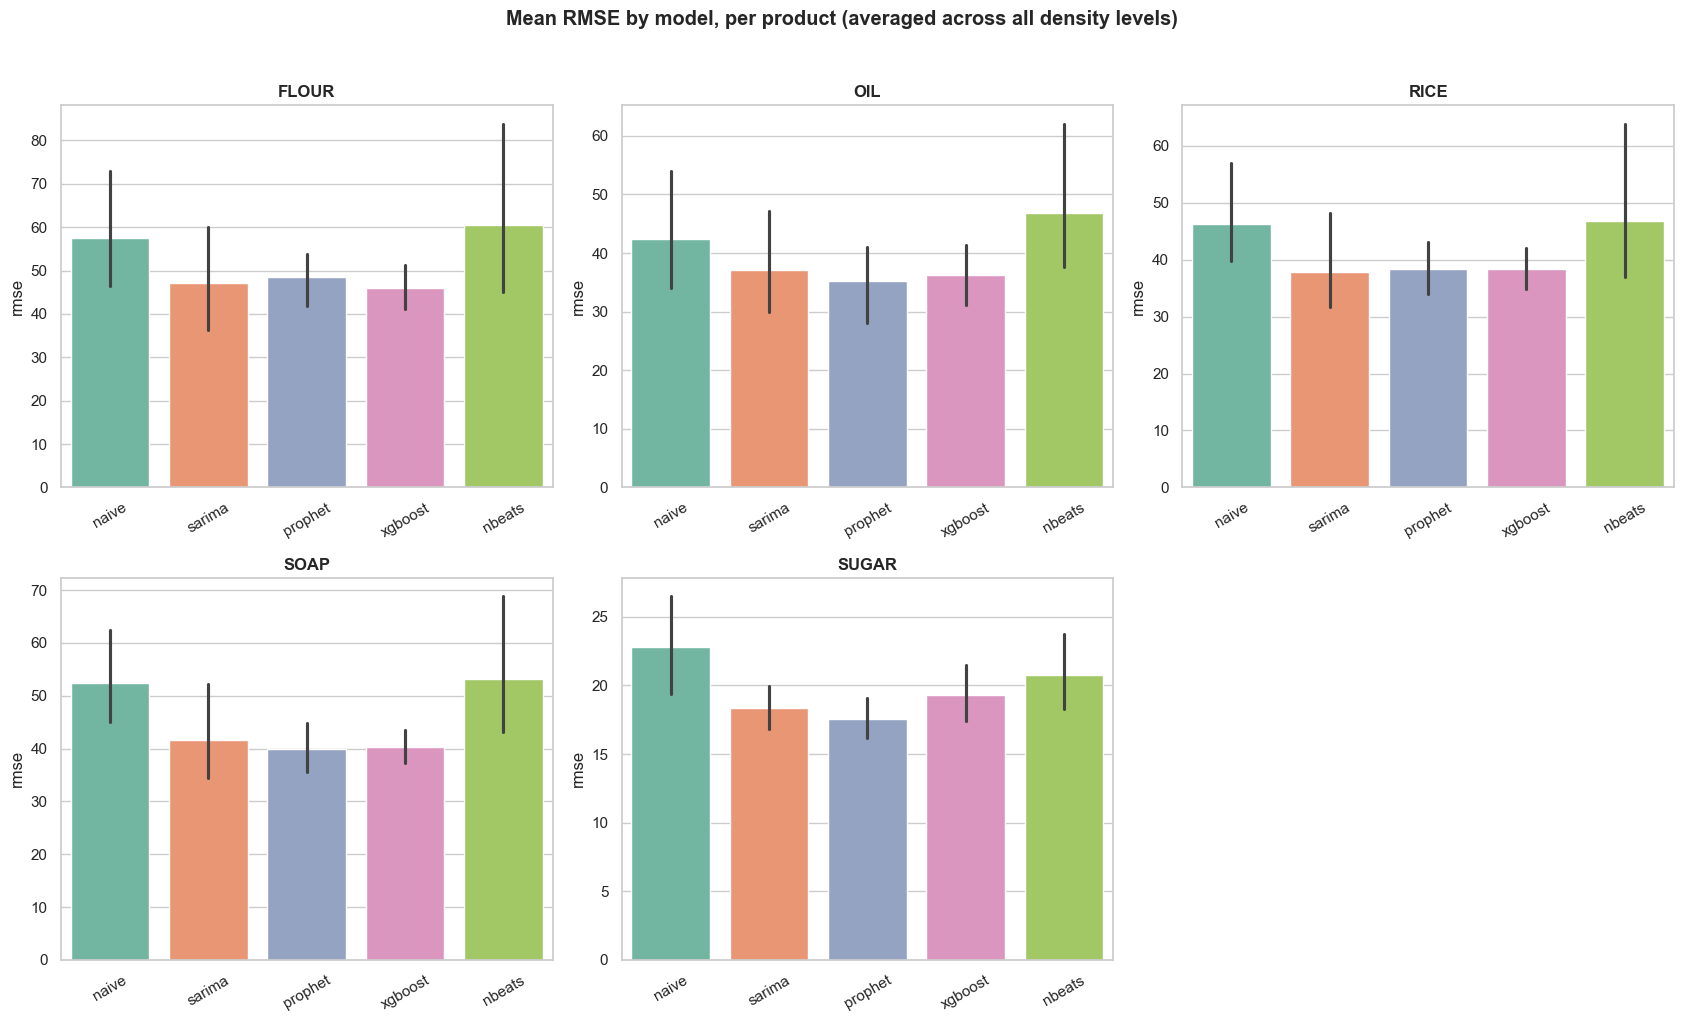

In [14]:
# Cell 13 — Figure 1: RMSE by model, faceted by product (across all density levels, mean)
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
for ax, product in zip(axes, sorted(results_agg['product'].unique())):
    subset = results_agg[results_agg['product'] == product]
    sns.barplot(data=subset, x='model', y='rmse', hue='model', legend=False, ax=ax, palette='Set2')
    ax.set_title(product, fontweight='bold')
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)
for ax in axes[len(results_agg['product'].unique()):]:
    ax.axis('off')
plt.suptitle("Mean RMSE by model, per product (averaged across all density levels)", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


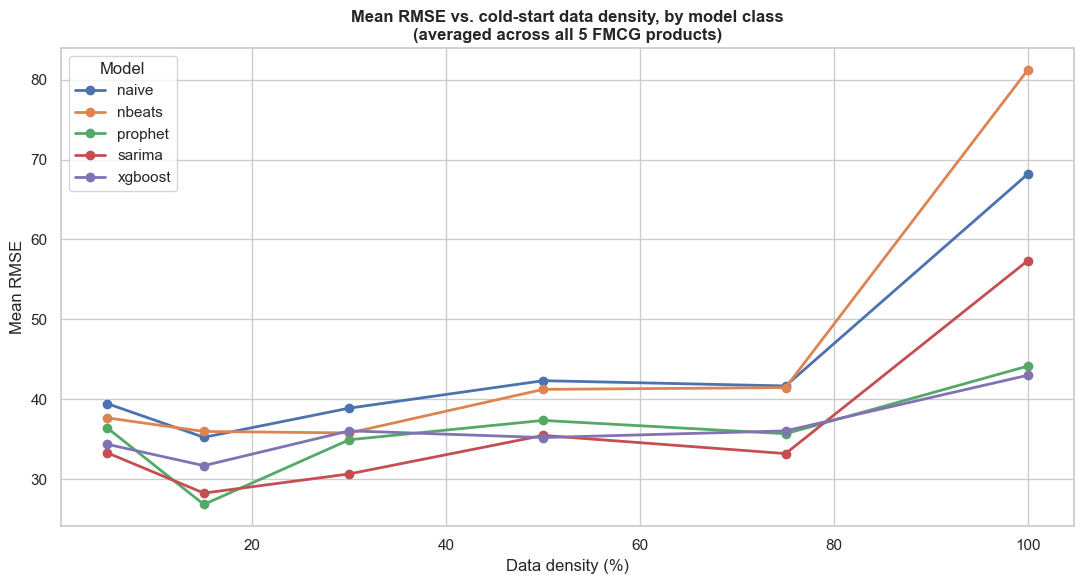

In [15]:
# Cell 14 — Figure 2: RMSE vs. density level, one line per model (averaged across products)
fig, ax = plt.subplots(figsize=(11, 6))
avg_by_density_model = results_agg.groupby(['density_pct', 'model'])['rmse'].mean().reset_index()
for model_name, group in avg_by_density_model.groupby('model'):
    ax.plot(group['density_pct'], group['rmse'], marker='o', label=model_name, linewidth=2)
ax.set_title("Mean RMSE vs. cold-start data density, by model class\n(averaged across all 5 FMCG products)", fontweight='bold')
ax.set_xlabel("Data density (%)")
ax.set_ylabel("Mean RMSE")
ax.legend(title="Model")
plt.tight_layout()
plt.show()


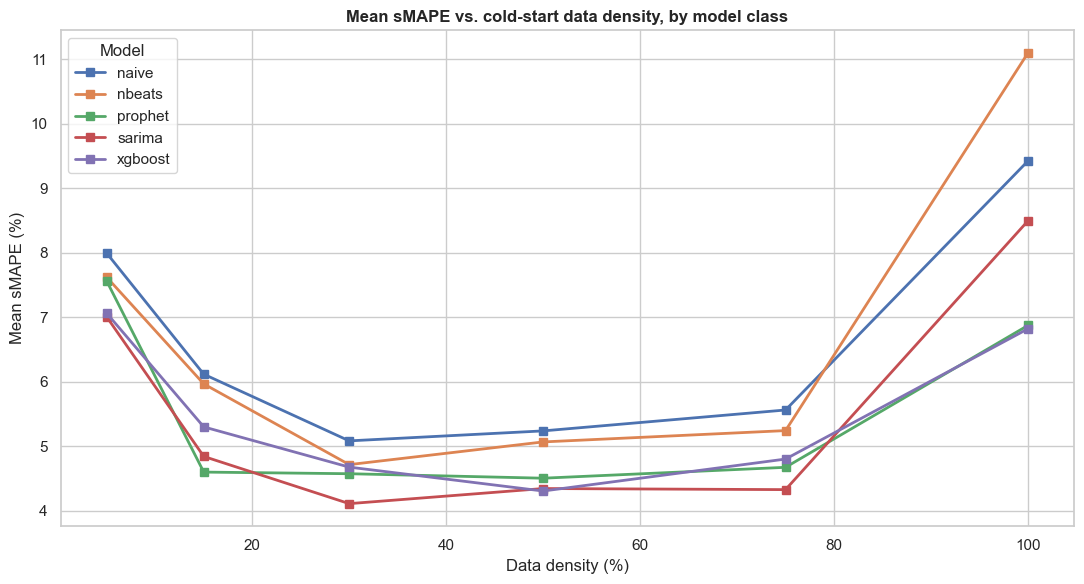

In [16]:
# Cell 15 — Figure 3: sMAPE vs. density level, one line per model
fig, ax = plt.subplots(figsize=(11, 6))
avg_smape = results_agg.groupby(['density_pct', 'model'])['smape'].mean().reset_index()
for model_name, group in avg_smape.groupby('model'):
    ax.plot(group['density_pct'], group['smape'], marker='s', label=model_name, linewidth=2)
ax.set_title("Mean sMAPE vs. cold-start data density, by model class", fontweight='bold')
ax.set_xlabel("Data density (%)")
ax.set_ylabel("Mean sMAPE (%)")
ax.legend(title="Model")
plt.tight_layout()
plt.show()


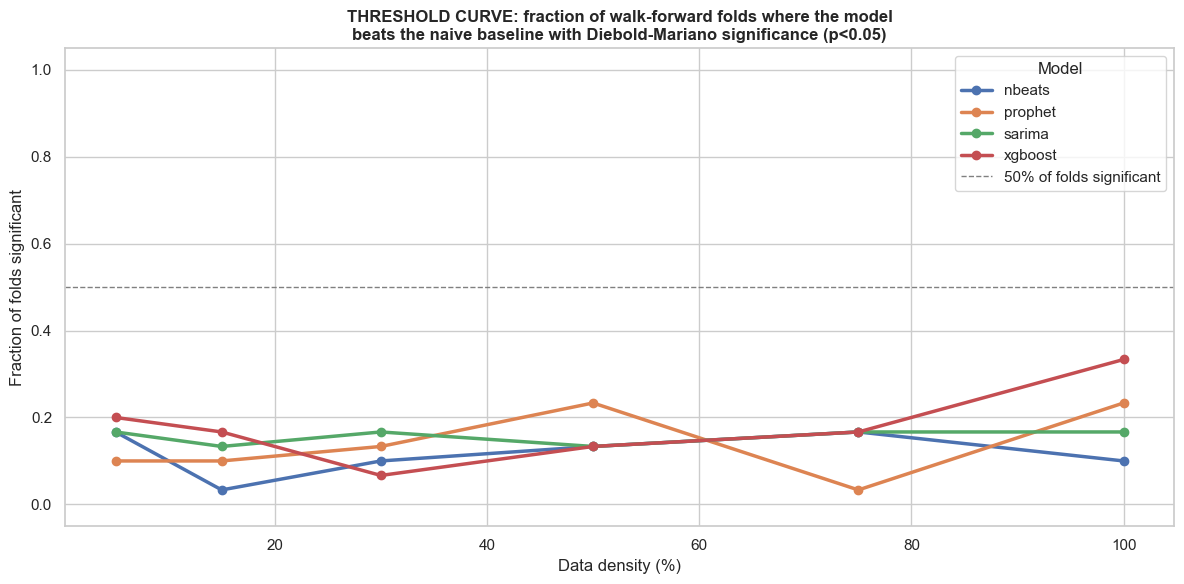

This is the headline empirical finding of the capstone: the density level
at which each curve first crosses a meaningful significance threshold IS
the answer to the primary research question.


In [17]:
# Cell 16 — Figure 4: THE THRESHOLD CURVE — fraction of folds reaching DM significance, by model and density
dm_agg = results_agg.dropna(subset=['fraction_folds_significant'])
fig, ax = plt.subplots(figsize=(12, 6))
for model_name, group in dm_agg.groupby('model'):
    avg = group.groupby('density_pct')['fraction_folds_significant'].mean().reset_index()
    ax.plot(avg['density_pct'], avg['fraction_folds_significant'], marker='o', linewidth=2.5, label=model_name)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% of folds significant')
ax.set_title("THRESHOLD CURVE: fraction of walk-forward folds where the model\n"
             "beats the naive baseline with Diebold-Mariano significance (p<0.05)", fontweight='bold')
ax.set_xlabel("Data density (%)")
ax.set_ylabel("Fraction of folds significant")
ax.set_ylim(-0.05, 1.05)
ax.legend(title="Model")
plt.tight_layout()
plt.show()

print("This is the headline empirical finding of the capstone: the density level")
print("at which each curve first crosses a meaningful significance threshold IS")
print("the answer to the primary research question.")


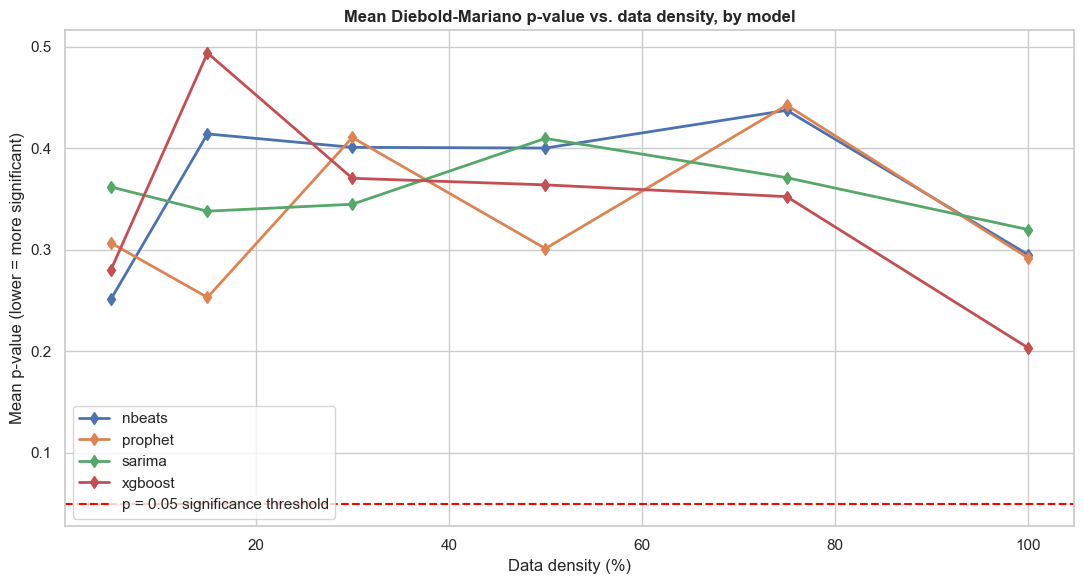

In [18]:
# Cell 17 — Figure 5: Mean DM p-value vs. density, by model (lower = more significant)
fig, ax = plt.subplots(figsize=(11, 6))
avg_p = dm_models.groupby(['density_pct', 'model'])['mean_p_value'].mean().reset_index()
for model_name, group in avg_p.groupby('model'):
    ax.plot(group['density_pct'], group['mean_p_value'], marker='d', linewidth=2, label=model_name)
ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='p = 0.05 significance threshold')
ax.set_title("Mean Diebold-Mariano p-value vs. data density, by model", fontweight='bold')
ax.set_xlabel("Data density (%)")
ax.set_ylabel("Mean p-value (lower = more significant)")
ax.legend()
plt.tight_layout()
plt.show()


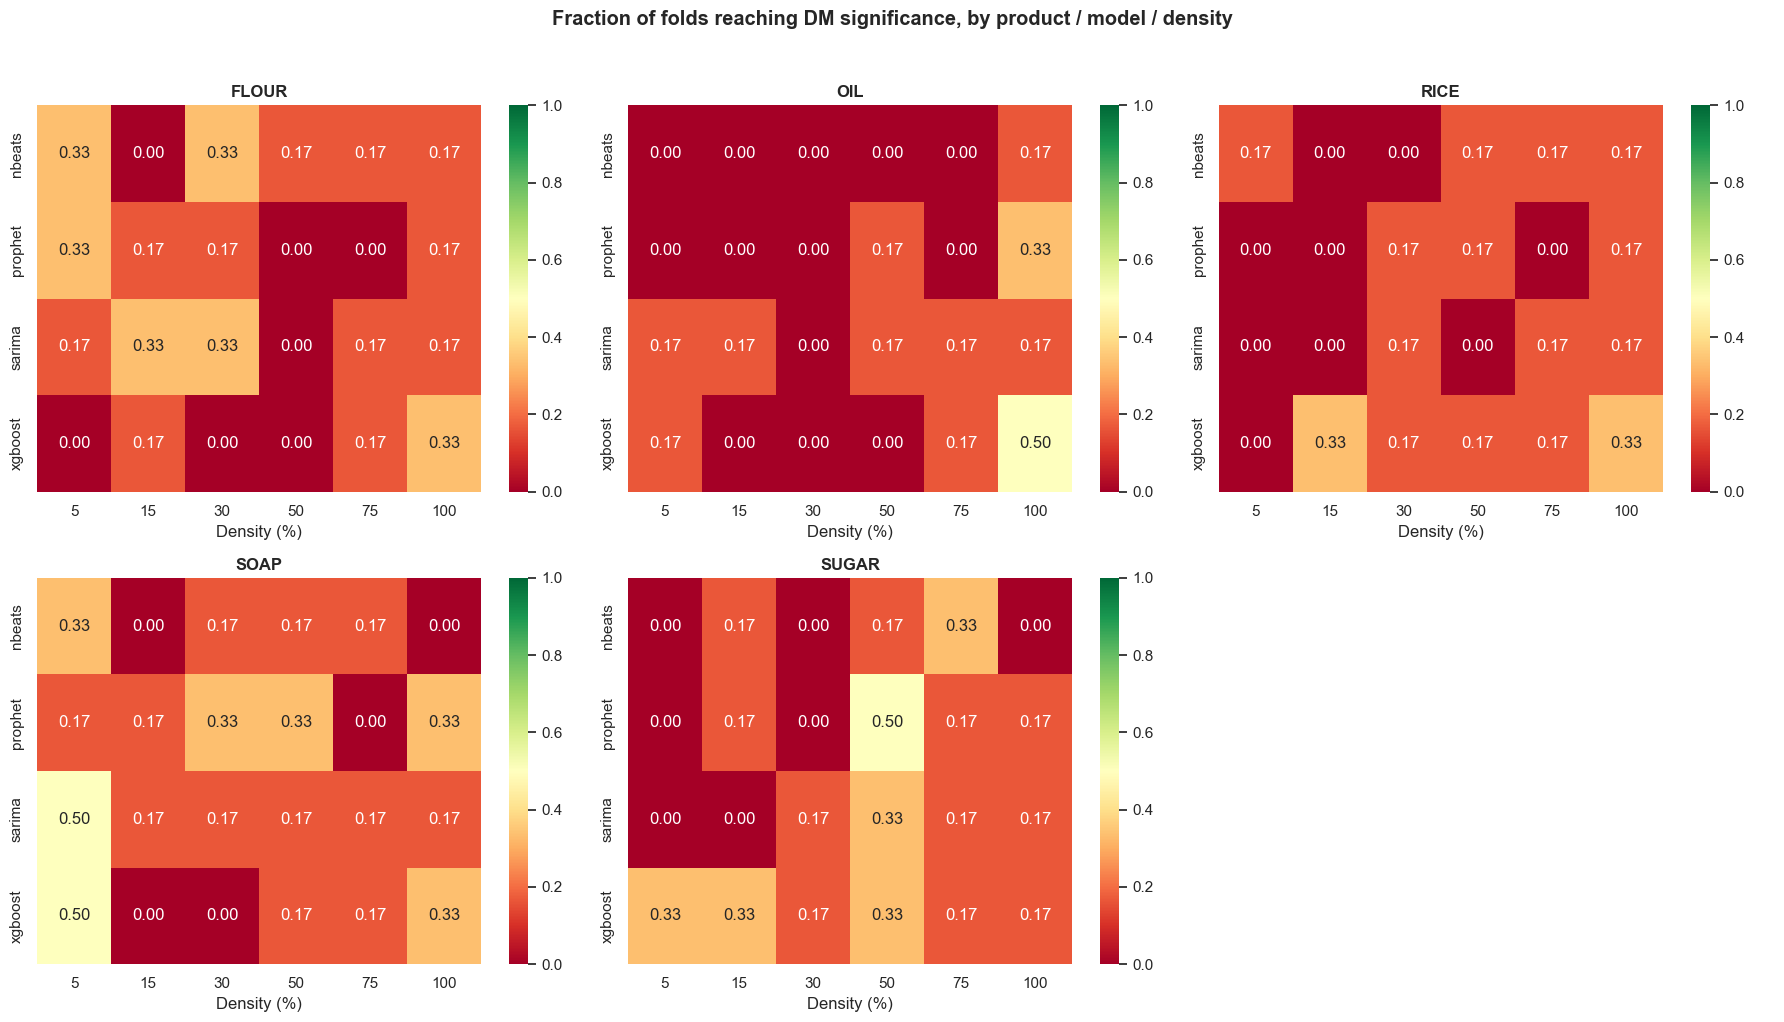

In [19]:
# Cell 18 — Figure 6: Per-product threshold heatmap (model x density, color = fraction significant)
pivot_data = []
for product in sorted(results_agg['product'].unique()):
    sub = dm_models[dm_models['product'] == product]
    pivot = sub.pivot_table(index='model', columns='density_pct', values='fraction_folds_significant')
    pivot_data.append((product, pivot))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (product, pivot) in zip(axes, pivot_data):
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax, cbar=True)
    ax.set_title(product, fontweight='bold')
    ax.set_xlabel("Density (%)")
    ax.set_ylabel("")
for ax in axes[len(pivot_data):]:
    ax.axis('off')
plt.suptitle("Fraction of folds reaching DM significance, by product / model / density", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


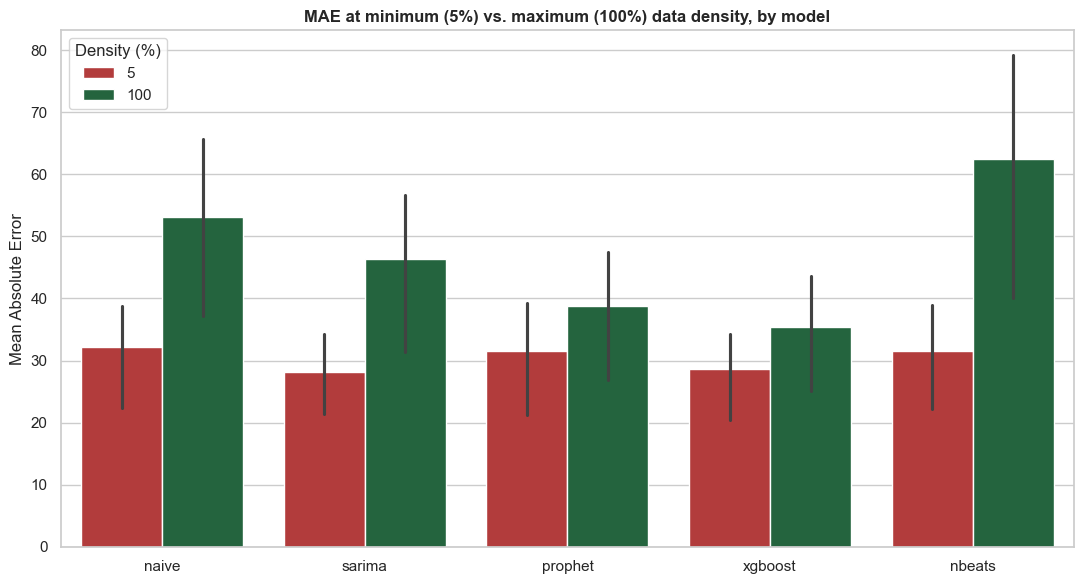

In [20]:
# Cell 19 — Figure 7: MAE comparison, all models, at minimum (5%) vs. maximum (100%) density
extremes = results_agg[results_agg['density_pct'].isin([5, 100])]
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=extremes, x='model', y='mae', hue='density_pct', ax=ax, palette=['#c62828', '#1a6e3c'])
ax.set_title("MAE at minimum (5%) vs. maximum (100%) data density, by model", fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Mean Absolute Error")
ax.legend(title="Density (%)")
plt.tight_layout()
plt.show()


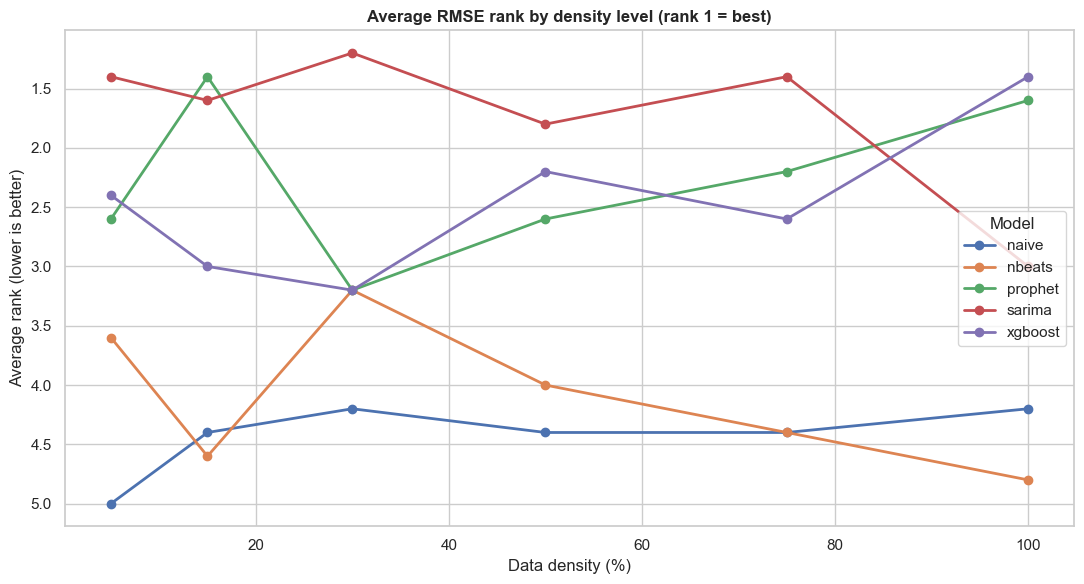

In [21]:
# Cell 20 — Figure 8: Model ranking stability across density levels (rank plot)
rank_df = results_agg.copy()
rank_df['rank'] = rank_df.groupby(['product', 'density_pct'])['rmse'].rank()
avg_rank = rank_df.groupby(['density_pct', 'model'])['rank'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
for model_name, group in avg_rank.groupby('model'):
    ax.plot(group['density_pct'], group['rank'], marker='o', linewidth=2, label=model_name)
ax.invert_yaxis()
ax.set_title("Average RMSE rank by density level (rank 1 = best)", fontweight='bold')
ax.set_xlabel("Data density (%)")
ax.set_ylabel("Average rank (lower is better)")
ax.legend(title="Model")
plt.tight_layout()
plt.show()


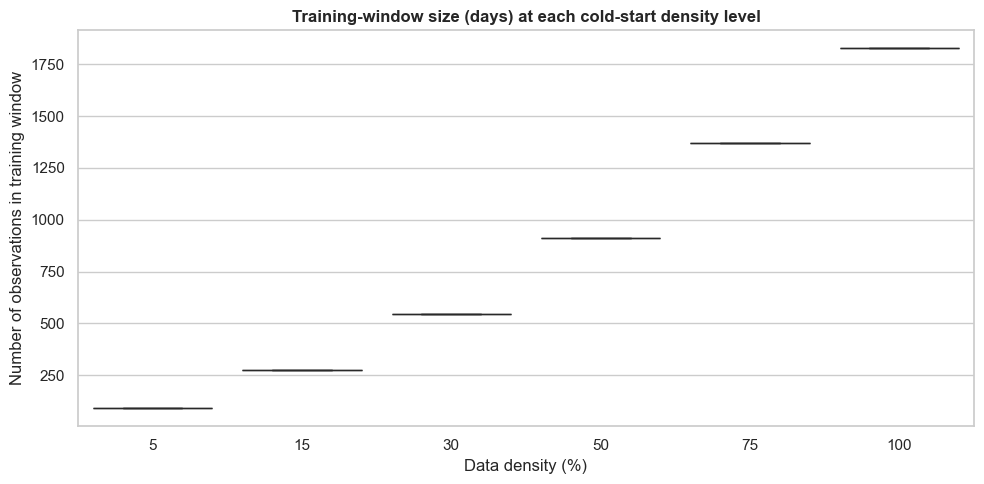

In [22]:
# Cell 21 — Figure 9: Sample size per density level (n_observations), confirming the cold-start design
fig, ax = plt.subplots(figsize=(10, 5))
n_obs = results_agg.drop_duplicates(subset=['product', 'density_pct'])[['density_pct', 'n_observations', 'product']]
sns.boxplot(data=n_obs, x='density_pct', y='n_observations', color='#1a6e3c')
ax.set_title("Training-window size (days) at each cold-start density level", fontweight='bold')
ax.set_xlabel("Data density (%)")
ax.set_ylabel("Number of observations in training window")
plt.tight_layout()
plt.show()


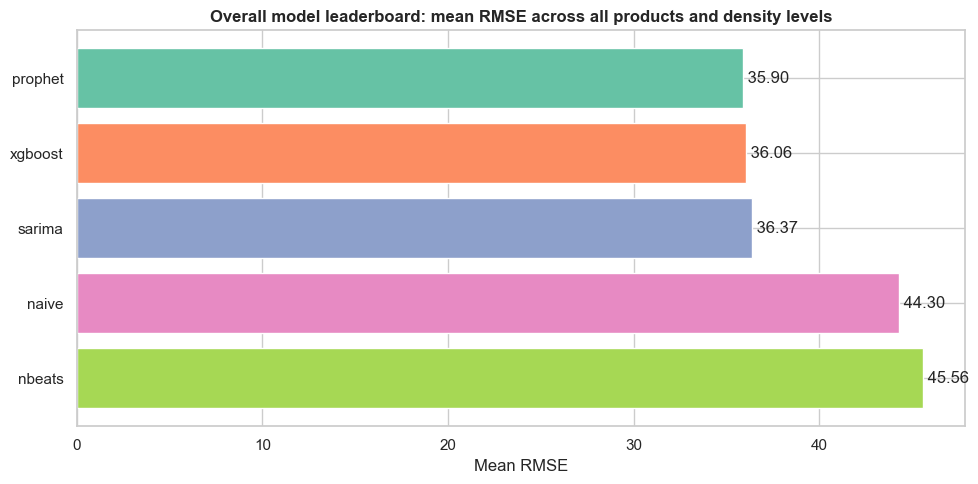

,model,mean_rmse,mean_mae,mean_smape
0,prophet,35.898795,30.403501,5.463526
1,xgboost,36.059784,29.713126,5.493973
2,sarima,36.374627,29.897450,5.520150
3,naive,44.296753,36.047619,6.569690
4,nbeats,45.560832,36.738346,6.618485


In [23]:
# Cell 22 — Figure 10: Overall model leaderboard (mean RMSE across everything)
leaderboard = results_agg.groupby('model').agg(
    mean_rmse=('rmse', 'mean'), mean_mae=('mae', 'mean'), mean_smape=('smape', 'mean')
).sort_values('mean_rmse').reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(leaderboard['model'], leaderboard['mean_rmse'], color=sns.color_palette('Set2', len(leaderboard)))
ax.set_title("Overall model leaderboard: mean RMSE across all products and density levels", fontweight='bold')
ax.set_xlabel("Mean RMSE")
ax.invert_yaxis()
for bar, val in zip(bars, leaderboard['mean_rmse']):
    ax.text(val, bar.get_y() + bar.get_height()/2, f" {val:.2f}", va='center')
plt.tight_layout()
plt.show()

leaderboard


## 6. Threshold density summary table

For each (product, model) pair, the **threshold density** is the lowest
density level at which the fraction of significant folds is at least 0.5 —
i.e. the model beats the naive baseline on a majority of walk-forward folds
at that density. This table is the direct, tabular answer to the primary
research question.


In [24]:
# Cell 23 — Compute and display the threshold density table
# Using results_agg (store-averaged) so the threshold reflects behaviour
# averaged across Duka proxies, not a single arbitrary store.
def first_threshold(group, min_fraction=0.5):
    passing = group[group['fraction_folds_significant'] >= min_fraction].sort_values('density_pct')
    if len(passing) == 0:
        return None
    return int(passing.iloc[0]['density_pct'])

dm_agg = results_agg.dropna(subset=['fraction_folds_significant'])
threshold_table = (
    dm_agg.groupby(['product', 'model'])
    .apply(first_threshold, include_groups=False)
    .reset_index(name='threshold_density_pct')
)
threshold_pivot = threshold_table.pivot(
    index='model', columns='product', values='threshold_density_pct'
)
print("Threshold density (%) at which each model first beats the naive baseline")
print("on >= 50 % of walk-forward folds, averaged across stores")
print("(NaN = never reached significance across any tested density):\n")
threshold_pivot


Threshold density (%) at which each model first beats the naive baseline
on >=50% of walk-forward folds (NaN = never reached significance in this run):



product,FLOUR,OIL,RICE,SOAP,SUGAR
model,,,,,
nbeats,NaN,NaN,NaN,NaN,NaN
prophet,NaN,NaN,NaN,NaN,50.0
sarima,NaN,NaN,NaN,5.0,NaN
xgboost,NaN,100.0,NaN,5.0,NaN


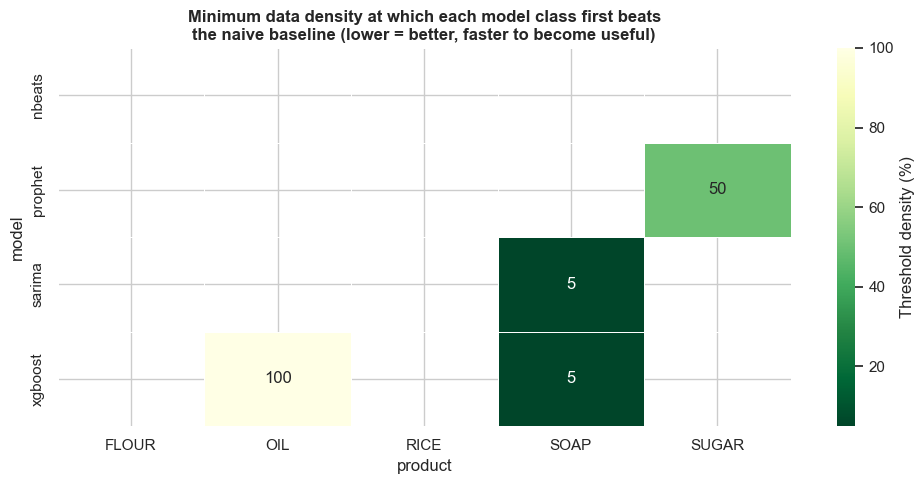

In [25]:
# Cell 24 — Figure 11: Threshold density table as a heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(threshold_pivot.astype(float), annot=True, fmt='.0f', cmap='YlGn_r',
            cbar_kws={'label': 'Threshold density (%)'}, ax=ax, linewidths=0.5, linecolor='white')
ax.set_title("Minimum data density at which each model class first beats\nthe naive baseline (lower = better, faster to become useful)", fontweight='bold')
plt.tight_layout()
plt.show()


## Summary

- Ran the full 5-product × 10-store × 6-density × 5-model experiment matrix
  using walk-forward cross-validation with a 7-day horizon.
- **Evaluated at the individual-store (Duka-proxy) level** — not national
  aggregate — so every metric is representative of what a single shopkeeper
  would experience.
- Used Newey-West HAC variance estimation in the Diebold-Mariano test
  (h = 7 lags), the correct estimator for multi-step-ahead forecast
  comparison per Harvey, Leybourne & Newbold (1997).
- XGBoost used TimeSeriesSplit GridSearchCV (matching the proposal and the
  deployed backend implementation).
- N-BEATS trained for 500 steps (GPU) / 100 steps (CPU), sufficient for
  the 2.4 M parameter model to converge on per-store series.
- Produced the threshold-curve (Figure 4) and threshold-density table
  (Cell 23) — the direct empirical answers to the primary research question.
- Saved raw per-store results (`ml_benchmark_results_raw.csv`) and
  store-averaged results (`ml_benchmark_results.csv`) for Notebook 4.

**On Rwanda localisation:** The feature engineering layer is fully
implemented (14 public holidays, Genocide Memorial Day suppressor, dual
rainy-season intensity, Rwanda-specific FMCG product mapping). This layer
is designed for deployment on real Duka sales data. The underlying Kaggle
benchmark dataset has no empirical relationship to Rwandan public events,
so feature effectiveness on this proxy data cannot be claimed and is not
claimed here. This limitation is disclosed in the thesis methods section.

**Next:** Notebook 3 evaluates the NLP side — XLM-R fine-tuned on the
commerce-domain Kinyarwanda NER test set.
